<a href="https://colab.research.google.com/github/Sedanuratess/makine-renmesi/blob/main/%C3%A7oklu_regresyon_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Makine öğrenmesinde ilerlemiş olduğum çoklu regresyon modelleri üzerine advertising.csv datasından yola çıkarak yapmış olduğum input-output ilişkilerini lineer regresyon modeli ile aşağıdaki gibi inceledim**

Adımlar:

1- Önce Datayı ham olarak inceleyelim

2- Datayı import edelim

3- Datayı inceleyelim (head, describe, info)

4- Datayı görselleştir

5- Modeli oluştur (formuller)

6- Hazırlık

7- Train-Test Split

8- Çoklu Lineer Regresyon Modelini Çalıştır (Fit)

9- Katsayıları incele (intercept_, coef_)

10- Tahmin Yap (Predict)

11- Gerçek Data ve Tahmin Datasını Çiz

12- Hataları Çiz ($y - \hat y$)

13- Model Doğruluğunu Kontrol Et (RMSE, ve $R^2$)

14- OLS - p-değerini incele

15- Korelasyon

16- Sonuçlara göre tekrar Model oluştur

In [ ]:
#1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv('/content/Advertising[1].csv',index_col=0)
df.head(5)

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


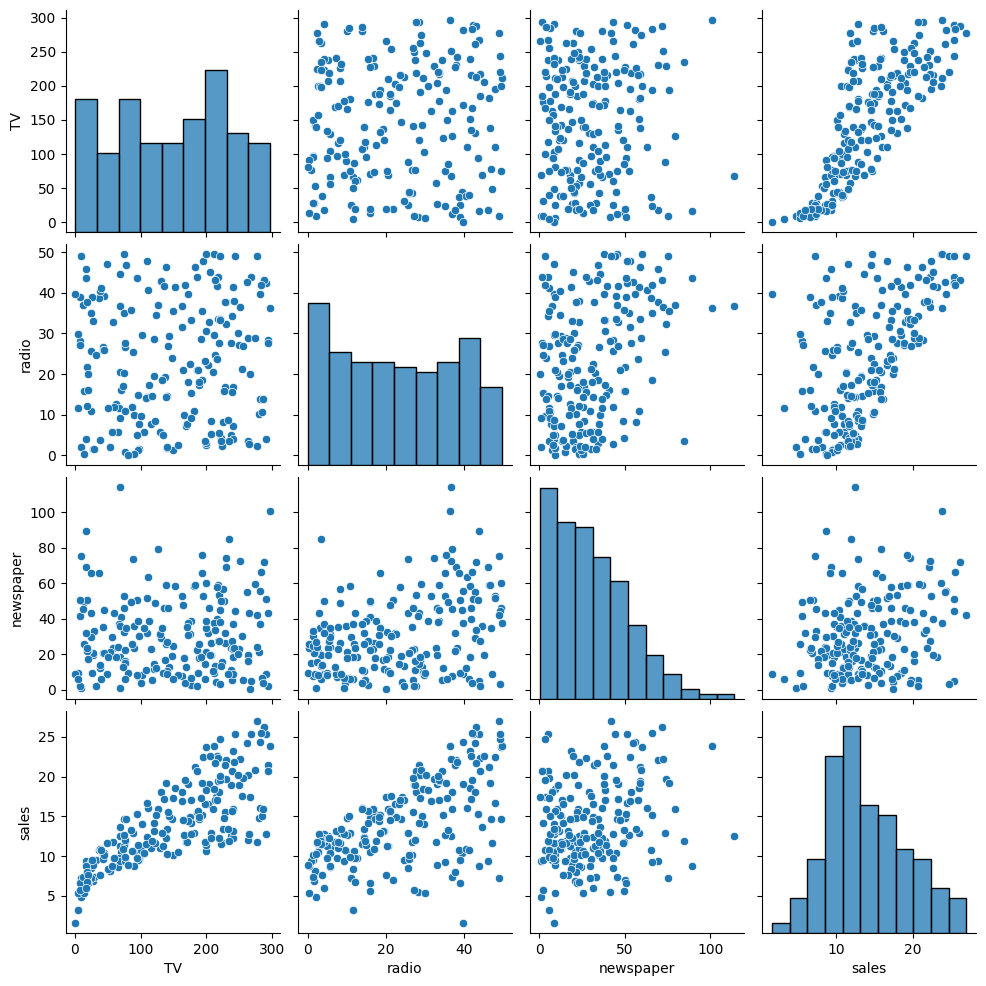

In [ ]:
#4
sns.pairplot(df)

In [ ]:
#inputlar
X=df[['TV','radio','newspaper']]
y=df[['sales']]

In [ ]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

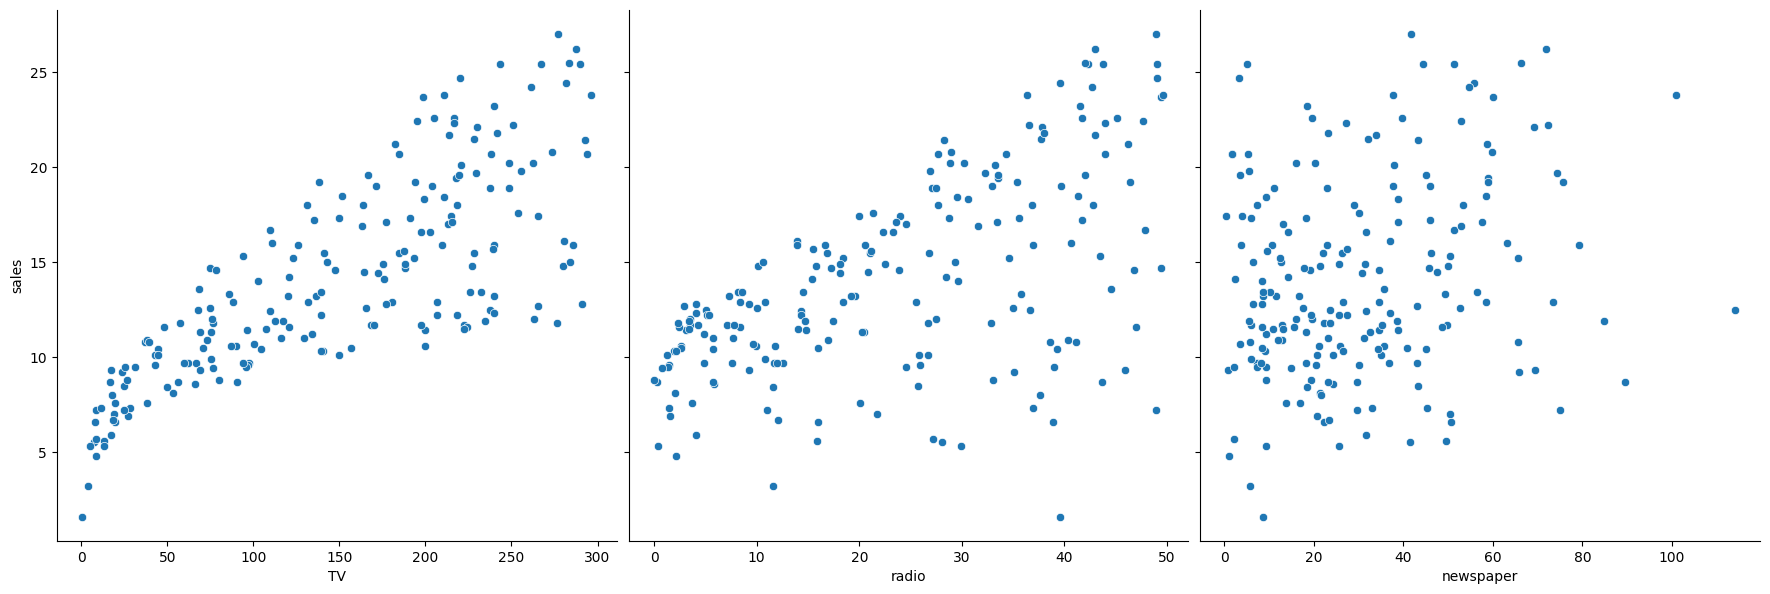

In [ ]:
#girdilere tek bakalım
sns.pairplot(df,x_vars=df.columns[:3],y_vars=df.columns[3],height=6)

In [ ]:
#modeli oluştur
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
#yeniden boyurlandırma reshape yaptık çünkü sklearnün linearregression classının istediği gibi değil.
X_r=X.values.reshape(-1,1)
y_r=y.values.reshape(-1,1)

In [ ]:
#train-test split
#train=%70 - test=%30
from sklearn.model_selection import train_test_split
# train data:X_train, y_train
# test_data: X_test, y_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=100)

In [ ]:
# şekiller

print("X_train'in boyutu:", X_train.shape)
print("y_train'in boyutu:", y_train.shape)

print("X_test'in boyutu:", X_test.shape)
print("y_test'in boyutu:", y_test.shape)

X_train'in boyutu: (140, 3)
y_train'in boyutu: (140, 1)
X_test'in boyutu: (60, 3)
y_test'in boyutu: (60, 1)


In [ ]:
#fit kısmı
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
#intercept ve coef hesabı
print('intercept:', lr.intercept_)
print('slope (coeffificent) eğim:', lr.coef_)

intercept: [2.65278967]
slope (coeffificent) eğim: [[0.0454256  0.18975773 0.00460308]]


In [ ]:
katsayilar = pd.DataFrame(lr.coef_, columns = ['beta_1 (TV)', 'beta_2 (Radio)', 'beta_3 (Newspaper)'])
katsayilar

,beta_1 (TV),beta_2 (Radio),beta_3 (Newspaper)
0,0.045426,0.189758,0.004603


In [ ]:
y_predict=lr.predict(X_test)
y_predict

array([[10.62160072],
       [20.00625302],
       [16.91850882],
       [19.17040746],
       [20.94974131],
       [13.12284284],
       [11.80740696],
       [12.32019766],
       [20.57806782],
       [20.95662688],
       [10.79096475],
       [19.54868702],
       [ 6.42403866],
       [15.23133391],
       [ 8.97226257],
       [ 7.89897862],
       [16.23599497],
       [12.02636477],
       [17.09702178],
       [11.26080277],
       [16.97826292],
       [ 9.75655721],
       [20.82389762],
       [17.20916742],
       [15.13816239],
       [21.97290698],
       [19.20181841],
       [10.07501899],
       [19.39017185],
       [14.8673761 ],
       [14.36798893],
       [ 7.55604543],
       [ 9.96742165],
       [14.76342565],
       [ 7.20995576],
       [13.60003295],
       [ 7.49088656],
       [11.70865932],
       [13.46091883],
       [15.2229793 ],
       [17.18088277],
       [13.56738329],
       [14.30942267],
       [13.72909849],
       [11.88559349],
       [ 8

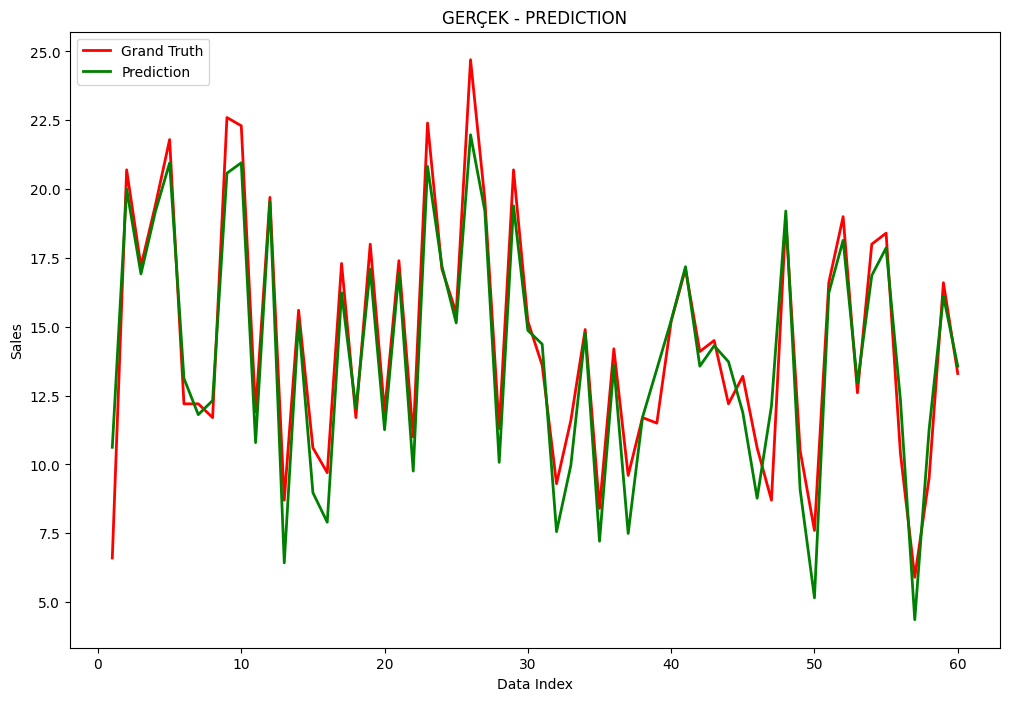

In [ ]:
# gerçek-tahmin datasını çizerken X_test girdi oluyor gerçek label y_test,tahmin_label y_predict oluyor
# Her bir tahmin noktasındaki değişimi görelim
indexler = range(1,61)

# Gerçek Data -> Grand Truth
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(indexler, y_test, label='Grand Truth', color='red', linewidth=2)

# Tahmin -> Prediction
ax.plot(indexler, y_predict, label='Prediction', color='green', linewidth=2)

plt.title('GERÇEK - PREDICTION')
plt.xlabel('Data Index')
plt.ylabel('Sales')
plt.legend(loc='upper left')
plt.show()

NameError: name 'np' is not defined

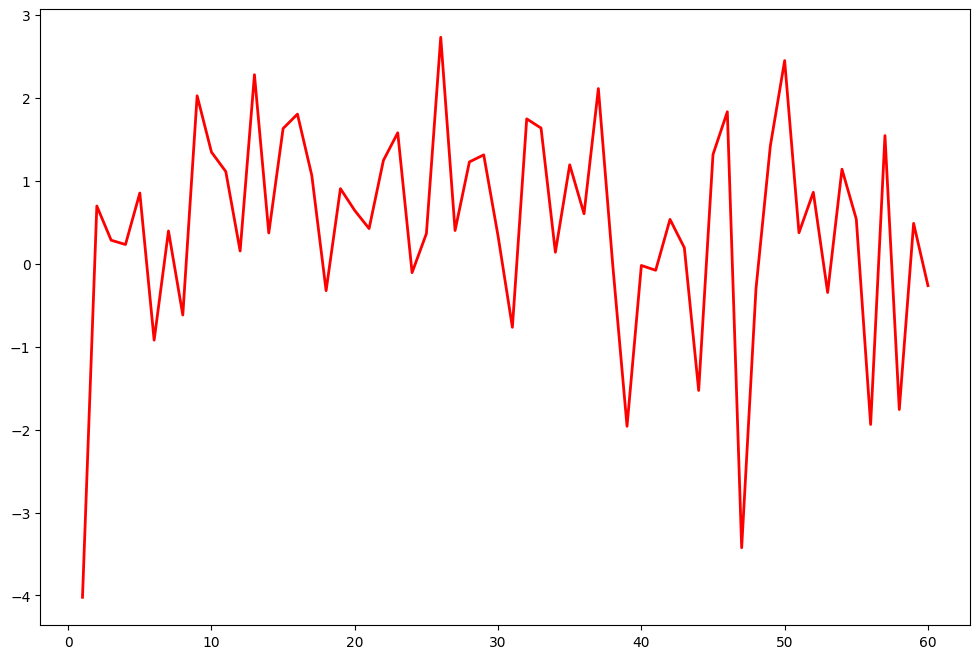

In [ ]:
# Her bir tahmin noktasındaki hatayı görelim
indexler = range(1,61)

# Residuls -> Hatalar
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(indexler, y_test - y_predict, label='Residuals', color='red', linewidth=2)

# sıfır doğrusunu çiz
ax.plot(indexler, np.zeros(60), color='black')

plt.title('HATALAR (RESIDUALS)')
plt.xlabel('Data Index')
plt.ylabel('Sales')
plt.legend(loc='upper left')
plt.show()

In [ ]:

from sklearn.metrics import r2_score, mean_squared_error
import math
r_2 = r2_score(y_test, y_predict)
print('R^2 %:', r_2 * 100)
mse = mean_squared_error(y_test, y_predict)
print('MSE:', mse)
#rmse
rmse = math.sqrt(mse)
print('RMSE:', rmse)

R^2 %: 90.58622107532246
MSE: 1.8506819941636963
RMSE: 1.3603977338130553


In [ ]:
# ols kısmı
import statsmodels.api as sm
X_train_ols=sm.add_constant(X_train)
X_train_ols

,const,TV,radio,newspaper
75,1.0,213.4,24.6,13.1
4,1.0,151.5,41.3,58.5
186,1.0,205.0,45.1,19.6
27,1.0,142.9,29.3,12.6
91,1.0,134.3,4.9,9.3
...,...,...,...,...
88,1.0,110.7,40.6,63.2
104,1.0,187.9,17.2,17.9
68,1.0,139.3,14.5,10.2
25,1.0,62.3,12.6,18.3


In [ ]:
sm_model=sm.OLS(y_train,X_train_ols)
sonuc=sm_model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     377.6
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           9.97e-66
Time:                        18:22:21   Log-Likelihood:                -280.83
No. Observations:                 140   AIC:                             569.7
Df Residuals:                     136   BIC:                             581.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6528      0.384      6.906      0.0

<Axes: >

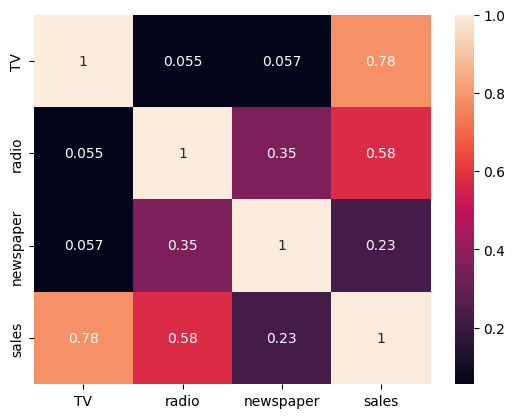

In [ ]:
#korelasyon
sns.heatmap(df.corr(),annot=True)

sonuca baktığımızda newspaper kolonu gerekmiyor önemzsiz diyebilriiz.

In [ ]:
X_train_yeni = X_train[['TV', 'radio']]
X_train_yeni.head()
X_test_yeni = X_test[['TV', 'radio']]
X_test_yeni.head()
lr.fit(X_train_yeni, y_train)
y_predict_yeni = lr.predict(X_test_yeni)
X_train_yeni_ols = sm.add_constant(X_train_yeni)
sm_model = sm.OLS(y_train, X_train_yeni_ols)
sonuc = sm_model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     568.8
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           4.46e-67
Time:                        18:25:40   Log-Likelihood:                -281.03
No. Observations:                 140   AIC:                             568.1
Df Residuals:                     137   BIC:                             576.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7190      0.368      7.392      0.0

**p değerlerine bakınca ikiside 0.05 ten küçük yani ikisi de önemli eğer büyük olsalardı büyük olanı çıkarıp tekrar yukarıdaki adımları işleyecektik ta ki tüm değişkenler öenmli olana kadar**
